In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the TSV file while skipping the first few lines
df = pd.read_csv("/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/RUN4/frequency_4_converted.tsv", delimiter="\t", header=None)

# Set the correct column names manually
df.columns = ['residue', 'ligand', 'frequency']

# Function to extract residue numbers from a string
def extract_residue_number(string):
    numbers = ''.join(filter(str.isdigit, string))
    return int(numbers) if numbers else 0

# Extract residue numbers from the 'residue' column
df['residue_numbers'] = df['residue'].apply(extract_residue_number)

# Sort the DataFrame by residue_numbers to maintain original order
df_sorted = df.sort_values(by='residue_numbers')

# Drop the auxiliary column used for sorting
df_sorted.drop(columns=['residue_numbers'], inplace=True)

# Save the sorted DataFrame to a new TSV file
df_sorted.to_csv("/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/RUN4/sorted_frequency.csv", sep='\t', index=False)


#####calculate the average value when the residue appears in each repeat; otherwise, delete it#######
import pandas as pd

# Define the paths to your CSV files
csv_files = [
    '/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/RUN2/sorted_frequency.csv',
    '/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/RUN3/sorted_frequency.csv',
    '/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/RUN4/sorted_frequency.csv'
]

# Read all CSV files into a list of dataframes and specify the correct separator
dfs = []
for f in csv_files:
    df = pd.read_csv(f, sep='\t')
    dfs.append(df)
    print(f"Columns in {f}: {df.columns.tolist()}")

# Assuming the columns are now correctly named, we can proceed with the rest of the script
common_residues = set(dfs[0]['residue'])
for df in dfs[1:]:
    common_residues.intersection_update(df['residue'])

# Filter dataframes to include only common residues
filtered_dfs = [df[df['residue'].isin(common_residues)] for df in dfs]

# Merge dataframes on 'residue' and 'ligand'
merged_df = pd.concat(filtered_dfs).groupby(['residue', 'ligand']).mean().reset_index()

# Save the result to a new CSV file
merged_df.to_csv('/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/average_sorted_frequency.csv', index=False)

print("Averaged contact frequencies saved to 'average_sorted_frequency.csv'.")


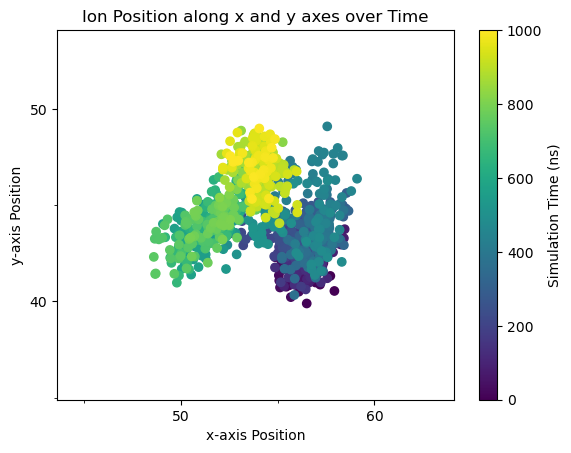

In [4]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

# Load the universe
u = mda.Universe("/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.gro", "/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.xtc")

# Select the ion (assuming 'resid 602' is the ion of interest)
ca = u.select_atoms('resid 602')

# Initialize lists to store the coordinates and time
x = []
y = []
z = []
time = []

# Iterate over each frame in the trajectory
for ts in u.trajectory:
    x.append(ca.positions[0, 0])  # x-coordinate of the first atom
    y.append(ca.positions[0, 1])  # y-coordinate of the first atom
    z.append(ca.positions[0, 2])  # z-coordinate of the first atom
    time.append(ts.time / 1000.0)  # time of the current frame in ns

# Convert lists to numpy arrays for easier handling
x = np.array(x)
y = np.array(y)
z = np.array(z)
time = np.array(time)

# Create a scatter plot of x and y coordinates, color-coded by simulation time in ns
plt.scatter(x, y, c=time, cmap='viridis')
plt.xlabel('x-axis Position')
plt.ylabel('y-axis Position')
plt.title('Ion Position along x and y axes over Time')
cbar = plt.colorbar(label='Simulation Time (ns)')
cbar.set_label('Simulation Time (ns)')
plt.ylim(min(y-5), max(y+5))  # Adjust y-axis limits based on data
plt.xlim(min(x-5), max(x+5))  # Adjust x-axis limits based on data

# Set up major and minor ticks
plt.gca().xaxis.set_major_locator(MultipleLocator(10))  # Set major locator for x-axis
plt.gca().xaxis.set_minor_locator(MultipleLocator(5))   # Set minor locator for x-axis
plt.gca().yaxis.set_major_locator(MultipleLocator(10))  # Set major locator for y-axis
plt.gca().yaxis.set_minor_locator(MultipleLocator(5))  # Set minor locator for y-axis

# Show the plot
plt.show()


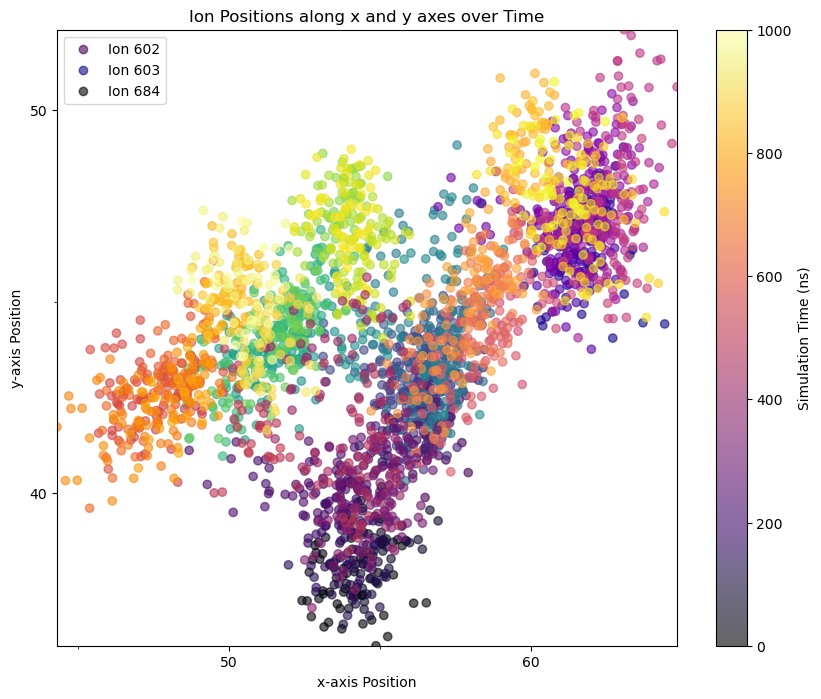

In [8]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

# Load the universe
u = mda.Universe("/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.gro", "/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.xtc")

# Select the ions (assuming 'resid 602', 'resid 603', and 'resid 683' are the ions of interest)
ions = [u.select_atoms(f'resid {resid}') for resid in [602, 603, 684]]

# Initialize lists to store the coordinates and time
coordinates = {resid: {'x': [], 'y': [], 'z': []} for resid in [602, 603, 684]}
time = []

# Iterate over each frame in the trajectory
for ts in u.trajectory:
    for resid, ion in zip([602, 603, 684], ions):
        coordinates[resid]['x'].append(ion.positions[0, 0])  # x-coordinate of the first atom
        coordinates[resid]['y'].append(ion.positions[0, 1])  # y-coordinate of the first atom
        coordinates[resid]['z'].append(ion.positions[0, 2])  # z-coordinate of the first atom
    time.append(ts.time / 1000.0)  # time of the current frame in ns

# Convert lists to numpy arrays for easier handling
for resid in [602, 603, 684]:
    coordinates[resid]['x'] = np.array(coordinates[resid]['x'])
    coordinates[resid]['y'] = np.array(coordinates[resid]['y'])
    coordinates[resid]['z'] = np.array(coordinates[resid]['z'])
time = np.array(time)

# Plot the positions of the ions
plt.figure(figsize=(10, 8))
for resid, color in zip([602, 603, 684], ['viridis', 'plasma', 'inferno']):
    plt.scatter(coordinates[resid]['x'], coordinates[resid]['y'], c=time, cmap=color, label=f'Ion {resid}', alpha=0.6)
    
plt.xlabel('x-axis Position')
plt.ylabel('y-axis Position')
plt.title('Ion Positions along x and y axes over Time')
plt.colorbar(label='Simulation Time (ns)')
plt.ylim(min(min(coordinates[resid]['y']) for resid in [602, 603, 684]), max(max(coordinates[resid]['y']) for resid in [602, 603, 684]))  # Adjust y-axis limits based on data
plt.xlim(min(min(coordinates[resid]['x']) for resid in [602, 603, 684]), max(max(coordinates[resid]['x']) for resid in [602, 603, 684]))  # Adjust x-axis limits based on data
plt.legend()

# Set up major and minor ticks
plt.gca().xaxis.set_major_locator(MultipleLocator(10))  # Set major locator for x-axis
plt.gca().xaxis.set_minor_locator(MultipleLocator(5))   # Set minor locator for x-axis
plt.gca().yaxis.set_major_locator(MultipleLocator(10))  # Set major locator for y-axis
plt.gca().yaxis.set_minor_locator(MultipleLocator(5))  # Set minor locator for y-axis

# Show the plot
plt.show()


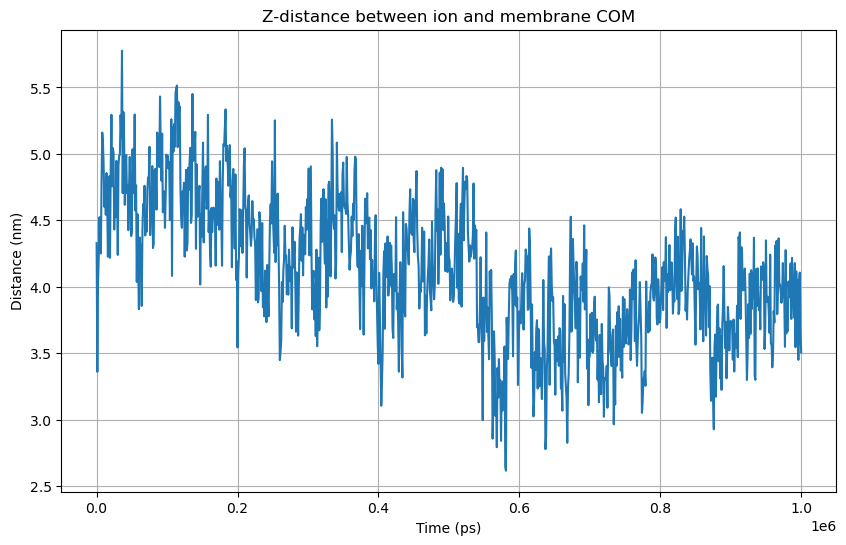

In [96]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

# Load the universe
u = mda.Universe("/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.gro", "/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.xtc")

# Select the membrane atoms and the ion atom
membrane = u.select_atoms('protein')  # Adjust the selection as needed
ion = u.select_atoms('resid 602')  # Adjust the selection as needed

# Ensure that a single atom is selected for the ion
if len(ion) != 1:
    raise ValueError("Ion selection must contain exactly one atom.")

# Store time and z-distance data
time = []
z_distances = []

# Iterate through the trajectory
for ts in u.trajectory:
    # Calculate the center of mass of the membrane
    com_membrane = membrane.center_of_mass()
    
    # Get the z-coordinate of the ion
    ion_z = ion.positions[0, 2]
    
    # Calculate the z-distance
    z_distance = np.abs(ion_z - com_membrane[2])
    
    # Store the time and z-distance
    time.append(ts.time)
    z_distances.append(z_distance)

# Convert to numpy arrays for easier handling
time = np.array(time)
z_distances = np.array(z_distances)

# Save the results to a file
np.savetxt('z_distances.dat', np.column_stack((time, z_distances)), header='Time(ps) Z-Distance(nm)')

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(time, z_distances, label='Z-distance')
plt.xlabel('Time (ps)')
plt.ylabel('Distance (nm)')
plt.title('Z-distance between ion and membrane COM')
#plt.legend()
plt.grid(True)
plt.show()


Loading universe...
Universe loaded.
Calculating z-distances...
Z-distances calculated.
Plotting z-distances...


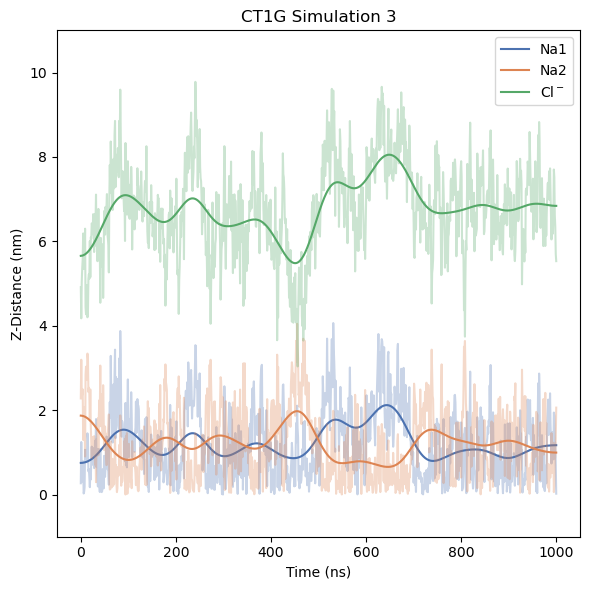

Plot completed.


In [117]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import seaborn as sns
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

def calculate_z_distance(universe, membrane_sel, ion_indices):
    membrane = universe.select_atoms(membrane_sel)
    ion_z_distances = {ion: [] for ion in ion_indices}
    time = []

    for ts in universe.trajectory:
        com_membrane = membrane.center_of_mass()

        for ion in ion_indices:
            ion_position = universe.atoms[ion].position
            z_distance = np.abs(ion_position[2] - com_membrane[2])
            ion_z_distances[ion].append(z_distance)

        time.append(ts.time/1000)

    time = np.array(time)
    for ion in ion_indices:
        ion_z_distances[ion] = np.array(ion_z_distances[ion])

    return time, ion_z_distances

def plot_z_distances(time, ion_z_distances, ion_indices, smoothing_sigma=30):
    plt.figure(figsize=(6, 6))
    # Define custom labels for ions with charge
    labels = {
        603: r'Na1',  # Sodium ion 2 with positive charge
        602: r'Na2',  # Sodium ion 1 with positive charge
        684: r'Cl$^-$'    # Chloride ion with negative charge
    }
    # Define a color palette
    colors = sns.color_palette("deep", len(ion_indices))  # You can choose other palettes from seaborn

    for i, ion in enumerate(ion_indices):
        z_distances = ion_z_distances[ion]
        plt.plot(time, z_distances, alpha=0.3, color=colors[i])
        smoothed_z_distances = gaussian_filter1d(z_distances, sigma=smoothing_sigma)
        plt.plot(time, smoothed_z_distances, label=f'{labels.get(ion, "Ion")}', color=colors[i])

    # Set x and y axis limits
    plt.xlim([-50, 1050])  # Set x-axis limits to -50 and 1050
    plt.ylim([-1, 11])     # Set y-axis limits to -1 and 10

    # Customize x-ticks
    plt.xticks(ticks=[0, 200, 400, 600, 800, 1000])  # Set specific x-tick locations

    # Customize y-ticks
    plt.yticks(ticks=[0, 2, 4, 6, 8, 10])  # Set specific y-tick locations

    # Customize ticks
    ax = plt.gca()
    #ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    #ax.xaxis.set_minor_locator(AutoMinorLocator(1))
    #ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    #ax.yaxis.set_minor_locator(AutoMinorLocator(1))
    plt.xlabel('Time (ns)')
    plt.ylabel('Z-Distance (nm)')
    plt.title('CT1G Simulation 3')
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.savefig('/Users/chenyifang/Desktop/RA/GAA/md/R3_ions_z.png', dpi=600, bbox_inches='tight')
    plt.show()
# Define the topology and trajectory files
top_file = "/Users/chenyifang/Desktop/RA/GAA/md/R3/md_center.gro"
traj_file = "/Users/chenyifang/Desktop/RA/GAA/md/R3/md_center.xtc"

# Define the selection strings
membrane_sel = 'resid 57:600'
ion_indices = [603, 602, 684]

# Load the universe
print("Loading universe...")
u = mda.Universe(top_file, traj_file)
print("Universe loaded.")

# Calculate z-distances
print("Calculating z-distances...")
time, ion_z_distances = calculate_z_distance(u, membrane_sel, ion_indices)
print("Z-distances calculated.")

# Plot z-distances
print("Plotting z-distances...")
plot_z_distances(time, ion_z_distances, ion_indices, smoothing_sigma=30)
print("Plot completed.")


Loading universe...
Universe loaded.
Calculating y-distances...
Y-distances calculated.
Sample y-distances: {602: array([22.25771882, 22.40257299, 21.65442822, 20.61685369, 21.11289393]), 603: array([23.08771683, 23.07257116, 22.48442814, 21.046854  , 21.96289431]), 684: array([21.74771668, 23.11257016, 21.74442837, 20.06685636, 21.00289332])}
Plotting y-distances...


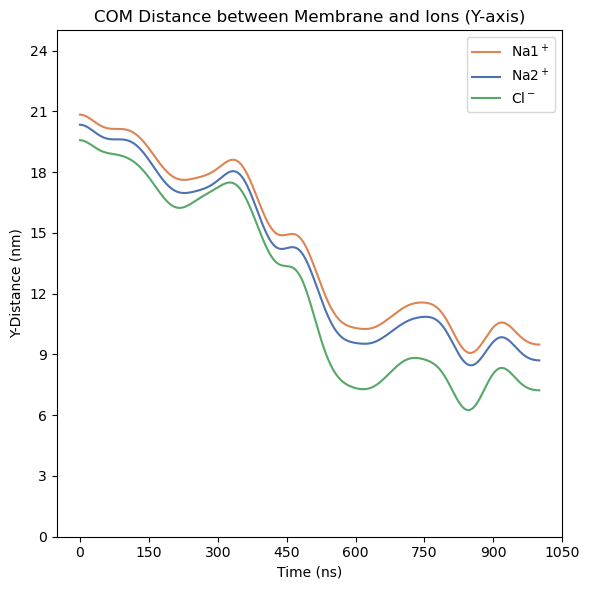

Plot completed.


In [91]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

def calculate_y_distance(universe, membrane_sel, ion_indices):
    membrane = universe.select_atoms(membrane_sel)
    ion_y_distances = {ion: [] for ion in ion_indices}
    time = []

    for ts in universe.trajectory:
        com_membrane = membrane.center_of_mass()

        for ion in ion_indices:
            ion_position = universe.atoms[ion].position
            y_distance = np.abs(ion_position[1] - com_membrane[1])
            ion_y_distances[ion].append(y_distance)

        time.append(ts.time / 1000)

    time = np.array(time)
    for ion in ion_indices:
        ion_y_distances[ion] = np.array(ion_y_distances[ion])

    return time, ion_y_distances

def plot_y_distances(time, ion_y_distances, ion_indices, smoothing_sigma=30):
    plt.figure(figsize=(6, 6))

    # Define custom labels for ions with charge
    labels = {
        603: r'Na1$^+$',  # Sodium ion 1 with positive charge
        602: r'Na2$^+$',  # Sodium ion 2 with positive charge
        684: r'Cl$^-$'    # Chloride ion with negative charge
    }

    # Define a color palette
    colors = sns.color_palette("deep", len(ion_indices))  # You can choose other palettes from seaborn

    # Order to plot: Na1 first, then Na2, then Cl
    plot_order = [603, 602, 684]

    # Collect handles and labels for legend
    handles = []
    for ion in plot_order:
        y_distances = ion_y_distances[ion]
        if len(y_distances) == 0:
            continue  # Skip if no distances are recorded
        smoothed_y_distances = gaussian_filter1d(y_distances, sigma=smoothing_sigma)
        handle, = plt.plot(time, smoothed_y_distances, label=f'{labels[ion]}', color=colors[ion_indices.index(ion)])
        handles.append(handle)

    # Set x and y axis limits
    plt.xlim([-50, 1050])  # Set x-axis limits to -50 and 1050
    plt.ylim([5, 25])     # Set y-axis limits to -1 and 10

    # Customize x-ticks
    plt.xticks(ticks=[0, 200, 400, 600, 800, 1000])  # Set specific x-tick locations

    # Customize y-ticks
    plt.yticks(ticks=[0, 2, 4, 6, 8])  # Set specific y-tick locations

    # Customize ticks
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_minor_locator(AutoMinorLocator(1))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_minor_locator(AutoMinorLocator(1))

    plt.xlabel('Time (ns)')
    plt.ylabel('Y-Distance (nm)')
    plt.title('COM Distance between Membrane and Ions (Y-axis)')
    plt.legend(handles=handles, labels=[labels[ion] for ion in plot_order])
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# Define the topology and trajectory files
top_file = "/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.gro"
traj_file = "/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.xtc"

# Define the selection strings
membrane_sel = 'resid 765:1025'
ion_indices = [602, 603, 684]

# Load the universe
print("Loading universe...")
u = mda.Universe(top_file, traj_file)
print("Universe loaded.")

# Calculate y-distances
print("Calculating y-distances...")
time, ion_y_distances = calculate_y_distance(u, membrane_sel, ion_indices)
print("Y-distances calculated.")

# Debugging: Check if distances are calculated
print("Sample y-distances:", {ion: dist[:5] for ion, dist in ion_y_distances.items()})

# Plot y-distances
print("Plotting y-distances...")
plot_y_distances(time, ion_y_distances, ion_indices, smoothing_sigma=30)
print("Plot completed.")


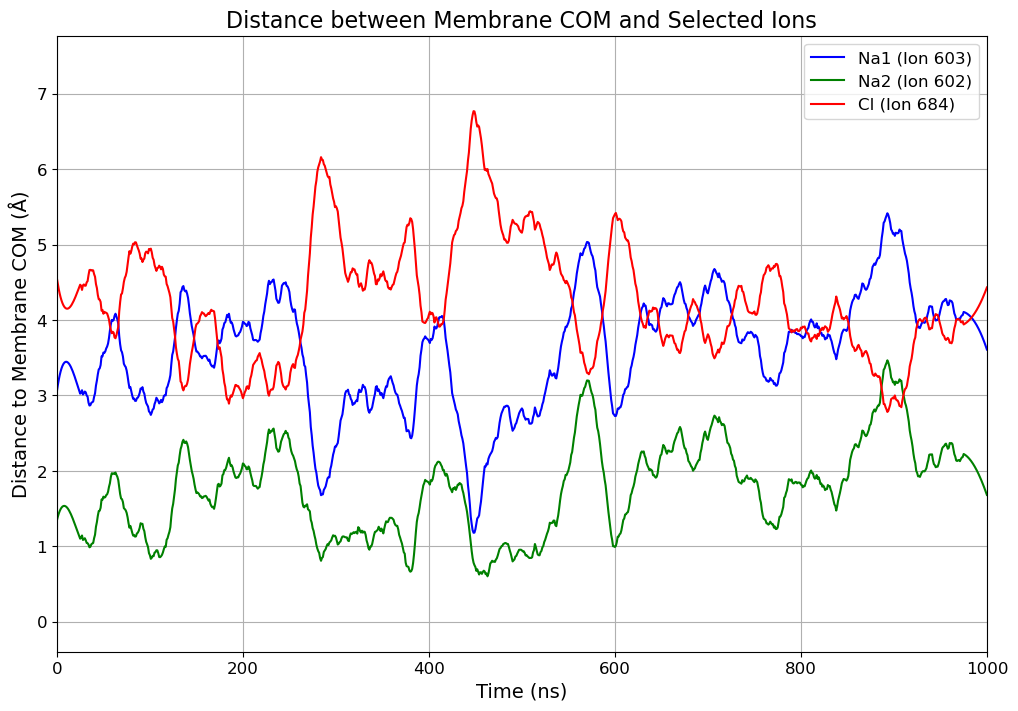

In [94]:
import MDAnalysis as mda
from MDAnalysis.analysis import align
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Load the trajectory and topology files
u = mda.Universe("/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.gro", "/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.xtc")

# Select the membrane and the specific ions
membrane = u.select_atoms("resname POPC")
ion1 = u.select_atoms("index 602")
ion2 = u.select_atoms("index 603")
ion3 = u.select_atoms("index 684")

# Prepare to store distances
distances_ion1 = []
distances_ion2 = []
distances_ion3 = []
times = []

# Iterate over trajectory frames
for ts in u.trajectory:
    com_membrane = membrane.center_of_mass()
    com_membrane_z = com_membrane[2]
    
    ion1_z = ion1.positions[0][2]
    ion2_z = ion2.positions[0][2]
    ion3_z = ion3.positions[0][2]
    
    distances_ion1.append(np.abs(com_membrane_z - ion1_z))
    distances_ion2.append(np.abs(com_membrane_z - ion2_z))
    distances_ion3.append(np.abs(com_membrane_z - ion3_z))
    
    # Store the time in nanoseconds
    times.append(ts.time / 1000)  # assuming time is in ps, convert to ns

# Apply Savitzky-Golay filter to smooth the data
window_length = 51  # Window length must be odd
polyorder = 3      # Polynomial order
distances_ion1_smooth = savgol_filter(distances_ion1, window_length, polyorder)
distances_ion2_smooth = savgol_filter(distances_ion2, window_length, polyorder)
distances_ion3_smooth = savgol_filter(distances_ion3, window_length, polyorder)

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(times, distances_ion1_smooth, label='Na1 (Ion 603)', color='blue')
plt.plot(times, distances_ion2_smooth, label='Na2 (Ion 602)', color='green')
plt.plot(times, distances_ion3_smooth, label='Cl (Ion 684)', color='red')

# Customizing the plot for publication quality
plt.xlabel('Time (ns)', fontsize=14)
plt.ylabel('Distance to Membrane COM (Å)', fontsize=14)
plt.title('Distance between Membrane COM and Selected Ions', fontsize=16)
plt.legend(fontsize=12)
plt.xlim([0, max(times)])
plt.ylim([min(min(distances_ion1_smooth), min(distances_ion2_smooth), min(distances_ion3_smooth)) - 1,
          max(max(distances_ion1_smooth), max(distances_ion2_smooth), max(distances_ion3_smooth)) + 1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)

# Save the figure
#plt.savefig("ion_membrane_distances.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


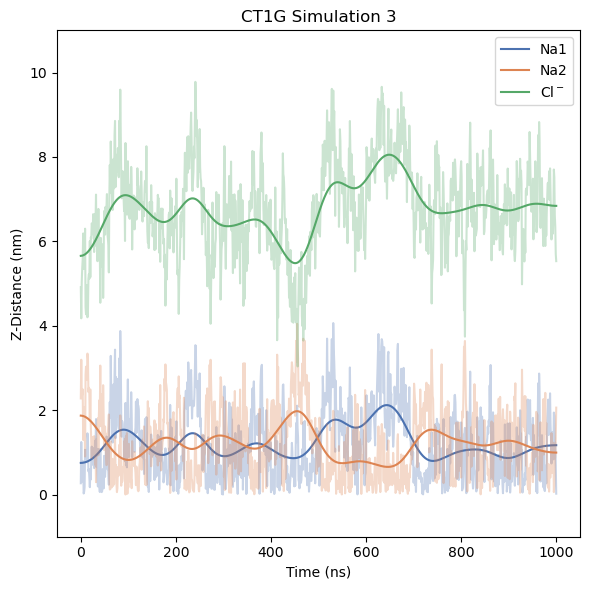

In [118]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import seaborn as sns
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

def calculate_z_distance(universe, protein_sel, ion_indices):
    protein = universe.select_atoms(protein_sel)
    ion_z_distances = {ion: [] for ion in ion_indices}
    time = []

    for ts in universe.trajectory:
        com_protein = protein.center_of_mass()

        for ion in ion_indices:
            ion_position = universe.atoms[ion].position
            z_distance = np.abs(ion_position[2] - com_protein[2])
            ion_z_distances[ion].append(z_distance)

        time.append(ts.time/1000)

    time = np.array(time)
    for ion in ion_indices:
        ion_z_distances[ion] = np.array(ion_z_distances[ion])

    return time, ion_z_distances

def plot_z_distances(time, ion_z_distances, ion_indices, smoothing_sigma=30):
    plt.figure(figsize=(6, 6))
    # Define custom labels for ions with charge
    labels = {
        603: r'Na1',  # Sodium ion 2 with positive charge
        602: r'Na2',  # Sodium ion 1 with positive charge
        684: r'Cl$^-$'    # Chloride ion with negative charge
    }
    # Define a color palette
    colors = sns.color_palette("deep", len(ion_indices))  

    for i, ion in enumerate(ion_indices):
        z_distances = ion_z_distances[ion]
        plt.plot(time, z_distances, alpha=0.3, color=colors[i])
        smoothed_z_distances = gaussian_filter1d(z_distances, sigma=smoothing_sigma)
        plt.plot(time, smoothed_z_distances, label=f'{labels.get(ion, "Ion")}', color=colors[i])

    # Set x and y axis limits
    plt.xlim([-50, 1050])  # Set x-axis limits to -50 and 1050
    plt.ylim([-1, 11])     # Set y-axis limits to -1 and 10

    # Customize x-ticks
    plt.xticks(ticks=[0, 200, 400, 600, 800, 1000])  # Set specific x-tick locations

    # Customize y-ticks
    plt.yticks(ticks=[0, 2, 4, 6, 8, 10])  # Set specific y-tick locations

    # Customize ticks
    ax = plt.gca()
    plt.xlabel('Time (ns)')
    plt.ylabel('Z-Distance (nm)')
    plt.title('CT1G Simulation 3')
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.savefig('/Users/chenyifang/Desktop/RA/GAA/md/R3_ions_z.png', dpi=600, bbox_inches='tight')
    plt.show()
# Define the topology and trajectory files
top_file = "/Users/chenyifang/Desktop/RA/GAA/md/R3/md_center.gro"
traj_file = "/Users/chenyifang/Desktop/RA/GAA/md/R3/md_center.xtc"

# Define the selection strings
protein_sel = 'resid 57:600'
ion_indices = [603, 602, 684]

# Load the universe
u = mda.Universe(top_file, traj_file)
time, ion_z_distances = calculate_z_distance(u, protein_sel, ion_indices)
plot_z_distances(time, ion_z_distances, ion_indices, smoothing_sigma=30)

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to load the data from a text file
def load_data(file_path):
    # Skip the first line (comment)
    data = pd.read_csv(file_path, delim_whitespace=True, comment='#')
    return data

# Load the data from three replicate simulations
file_paths = ['//SLC6A8_100/CT1C/R1/distance_com.txt', '/Users/chenyifang/Desktop/SLC6A8_100/CT1C/R2/distance_com.txt', '/Users/chenyifang/Desktop/SLC6A8_100/CT1C/R3/distance_com.txt']
data_list = [load_data(fp) for fp in file_paths]

# Concatenate data for each ion from all replicates
dNa1_all = pd.concat([data['dNa1.z'] for data in data_list])
dNa2_all = pd.concat([data['dNa2.z'] for data in data_list])
dCl_all = pd.concat([data['dCl.z'] for data in data_list])

# Create a DataFrame for easier plotting
data_combined = pd.DataFrame({
    'dNa1.z': dNa1_all,
    'dNa2.z': dNa2_all,
    'dCl.z': dCl_all
})

# Plotting the distributions
plt.figure(figsize=(10, 6))
sns.histplot(data_combined['dNa1.z'], kde=True, color='blue', label='Na1', stat='density')
sns.histplot(data_combined['dNa2.z'], kde=True, color='green', label='Na2', stat='density')
sns.histplot(data_combined['dCl.z'], kde=True, color='red', label='Cl', stat='density')

# Set labels and title
plt.xlabel('Distance along z-axis')
plt.ylabel('Density')
plt.title('Distribution of distances from membrane center to ions')
plt.legend()
plt.xlim([-50, 1050])
plt.ylim([-1, 10])
plt.xticks([0, 200, 400, 600, 800, 1000])
plt.yticks([0, 2, 4, 6, 8])

# Show plot
plt.show()


KeyError: 'dNa1.z'

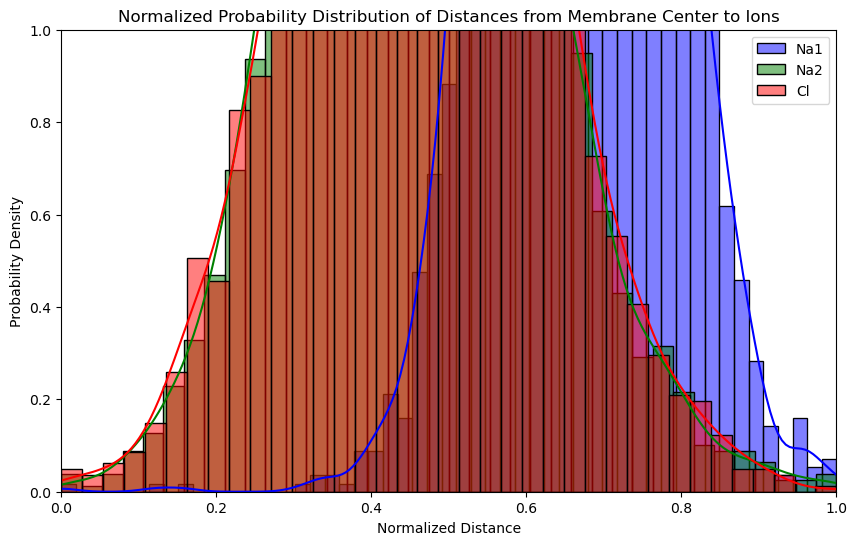

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from the CSV file
file_path = '/Users/chenyifang/Desktop/CT1C.csv'  # Replace with your file path
data = pd.read_csv(file_path)

# Normalize the distances for each ion
data_normalized = data.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# Plotting the probability distributions
plt.figure(figsize=(10, 6))
sns.histplot(data_normalized['Na1'], kde=True, color='blue', label='Na1', stat='density')
sns.histplot(data_normalized['Na2'], kde=True, color='green', label='Na2', stat='density')
sns.histplot(data_normalized['Cl'], kde=True, color='red', label='Cl', stat='density')

# Set labels and title
plt.xlabel('Normalized Distance')
plt.ylabel('Probability Density')
plt.title('Normalized Probability Distribution of Distances from Membrane Center to Ions')
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Show plot
plt.show()


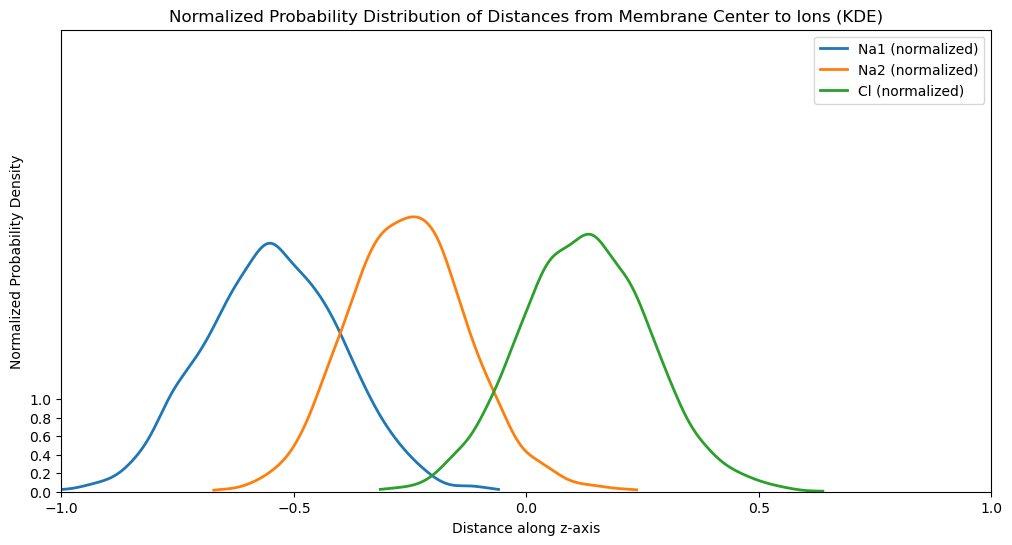

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# Load the data from the CSV file
file_path = '/Users/chenyifang/Desktop/CT1C.csv'  # Replace with your file path
data = pd.read_csv(file_path)

# Initialize a DataFrame to hold the KDE distributions
kde_data = pd.DataFrame()

# Define a function to calculate and normalize KDE
def calculate_kde(column):
    kde = gaussian_kde(column, bw_method='scott')
    x = np.linspace(column.min(), column.max(), 1000)
    kde_values = kde.evaluate(x)
    # Normalize KDE values such that the area under the curve is 1
    kde_values_normalized = kde_values / np.trapz(kde_values, x)
    return x, kde_values_normalized

# Calculate and store the KDE distributions for each ion
for ion in ['Na1', 'Na2', 'Cl']:
    x, kde_values_normalized = calculate_kde(data[ion])
    kde_data[ion] = pd.Series(x)
    kde_data[f'{ion}_probability'] = pd.Series(kde_values_normalized)

# Save the combined data to a new CSV file
combined_file_path = '/Users/chenyifang/Desktop/CT1C_kde_probabilities.csv'  # Replace with your desired output file path
kde_data.to_csv(combined_file_path, index=False)

# Plotting the KDE distributions (normalized)
plt.figure(figsize=(12, 6))

# Plotting normalized KDE distributions
for ion in ['Na1', 'Na2', 'Cl']:
    plt.plot(kde_data[ion], kde_data[f'{ion}_probability'], label=f'{ion} (normalized)', lw=2)

# Set labels and title
plt.xlabel('Distance along z-axis')
plt.ylabel('Normalized Probability Density')
plt.title('Normalized Probability Distribution of Distances from Membrane Center to Ions (KDE)')
plt.legend()
plt.xlim([-1, 1])  # Adjust x-axis limits based on your data range
plt.ylim([0, 5])   # Adjust y-axis limits based on your data range
plt.xticks([-1, -0.5, 0, 0.5, 1])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

# Show plot
plt.show()


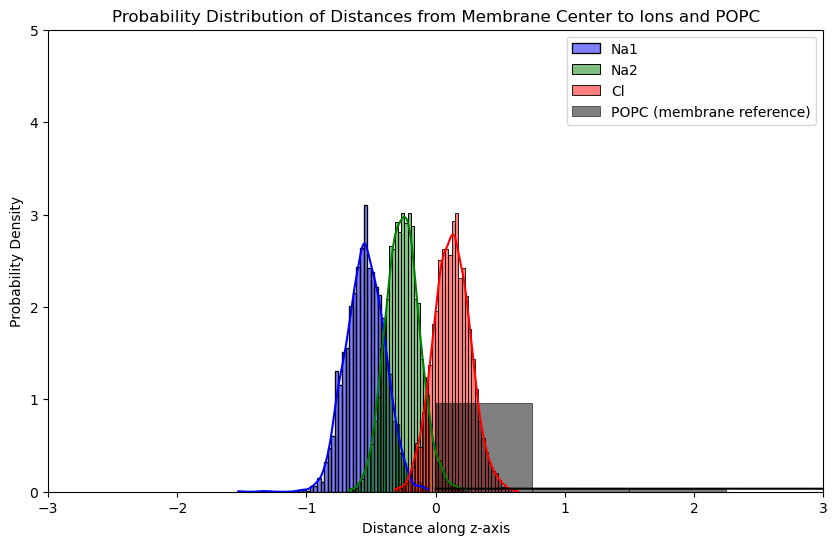

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from the CSV files
ion_file_path = '/Users/chenyifang/Desktop/CT1C.csv'  # Replace with your file path
popc_file_path = '/Users/chenyifang/Desktop/POPC_CT1C.csv'  # Replace with your file path for POPC positions

ion_data = pd.read_csv(ion_file_path)
popc_data = pd.read_csv(popc_file_path)

# Save the original data to new CSV files
ion_normalized_file_path = 'original_ion_data.csv'  # Replace with your desired output file path
popc_normalized_file_path = 'original_popc_data.csv'  # Replace with your desired output file path

ion_data.to_csv(ion_normalized_file_path, index=False)
popc_data.to_csv(popc_normalized_file_path, index=False)

# Plotting the probability distributions for ions and POPC positions (probability normalized)
plt.figure(figsize=(10, 6))

# Plotting ion distances
sns.histplot(ion_data['Na1'], kde=True, color='blue', label='Na1', stat='density')
sns.histplot(ion_data['Na2'], kde=True, color='green', label='Na2', stat='density')
sns.histplot(ion_data['Cl'], kde=True, color='red', label='Cl', stat='density')

# Plotting POPC positions
sns.histplot(popc_data['POPC'], kde=True, color='black', label='POPC (membrane reference)', stat='density')

# Set labels and title
plt.xlabel('Distance along z-axis')
plt.ylabel('Probability Density')
plt.title('Probability Distribution of Distances from Membrane Center to Ions and POPC')
plt.legend()
plt.xlim([-3, 3])  # Set x-axis limits based on your data range
plt.ylim([0, 5])   # Set y-axis limits based on your data range
plt.xticks([-3, -2, -1, 0, 1, 2, 3])
plt.yticks([0, 1, 2, 3, 4, 5])

# Show plot
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


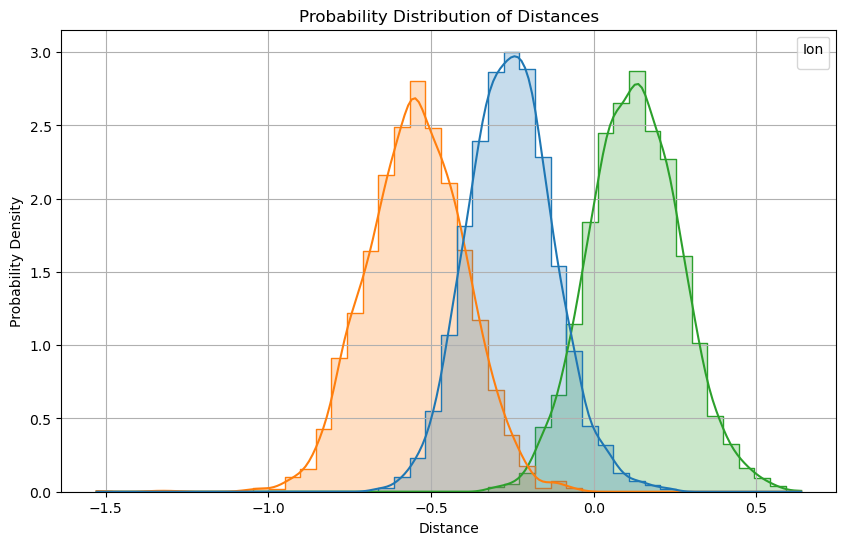

In [132]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('/Users/chenyifang/Desktop/CT1C.csv')

# Prepare data for plotting
melted_data = data.melt(var_name='Ion', value_name='Distance')

# Plot the probability distribution
plt.figure(figsize=(10, 6))
sns.histplot(melted_data, x='Distance', hue='Ion', stat='density', common_norm=False, element='step', kde=True)
plt.xlabel('Distance')
plt.ylabel('Probability Density')
plt.title('Probability Distribution of Distances')
plt.legend(title='Ion')
plt.grid(True)
plt.show()

# Normalize the distances
normalized_data = melted_data.groupby('Ion').apply(lambda x: x['Distance'] / x['Distance'].max()).reset_index(name='Normalized_Distance')

# Save the normalized data to a CSV file
normalized_data.to_csv('/Users/chenyifang/Desktop/CT1C_normalized_distances.csv', index=False)


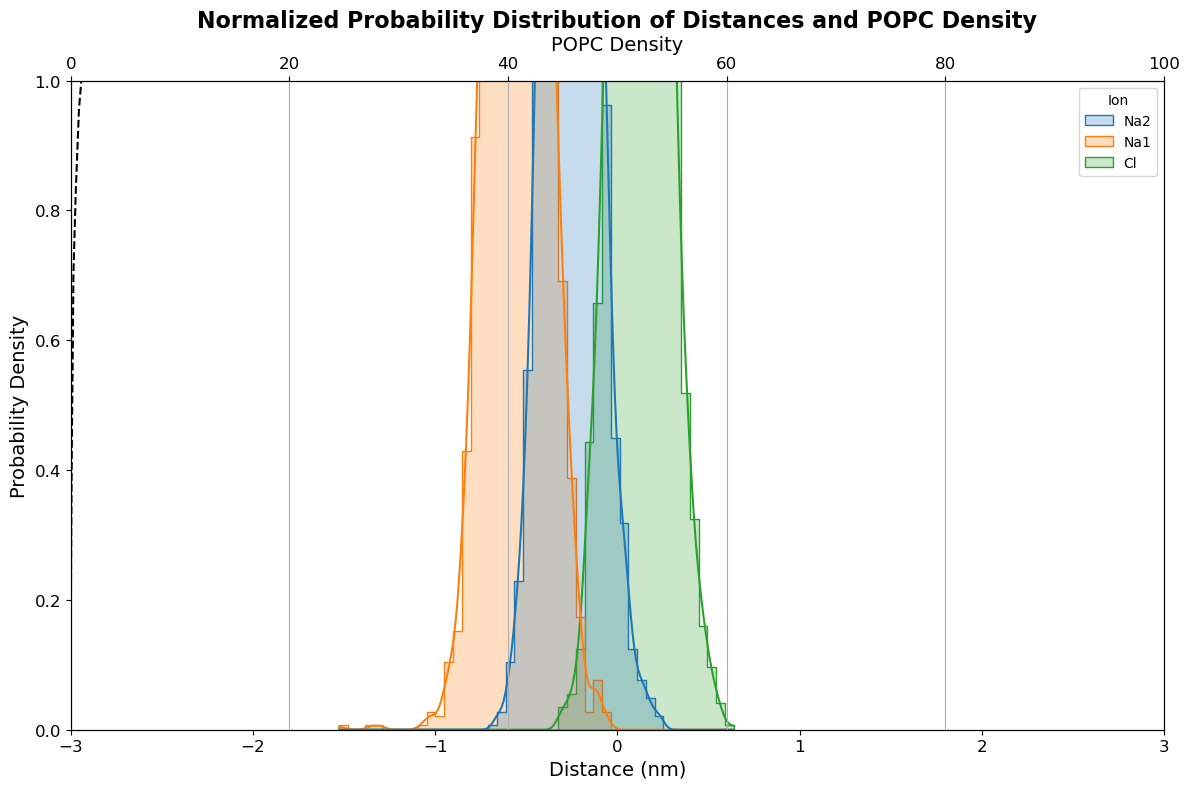

In [183]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Load the distance data
distance_data = pd.read_csv('/Users/chenyifang/Desktop/CT1C.csv')

# Prepare data for plotting
melted_distance_data = distance_data.melt(var_name='Ion', value_name='Distance')

# Calculate KDE and normalize probability distributions
def calculate_normalized_kde(column):
    kde = gaussian_kde(column, bw_method='scott')
    x = np.linspace(column.min(), column.max(), 1000)
    kde_values = kde.evaluate(x)
    kde_values_normalized = kde_values / np.trapz(kde_values, x)  # Normalize to make the area under the curve equal to 1
    return x, kde_values_normalized

# Calculate and store the KDE distributions
kde_data = pd.DataFrame()
for ion in distance_data.columns:
    x, kde_values_normalized = calculate_normalized_kde(distance_data[ion])
    kde_data[ion] = x
    kde_data[f'{ion}_probability'] = kde_values_normalized

# Save the combined data to a new CSV file with normalized probabilities
combined_file_path = '/Users/chenyifang/Desktop/CT1C_kde_probabilities.csv'
kde_data.to_csv(combined_file_path, index=False)

# Load the POPC density data
popc_density_data = pd.read_csv('/Users/chenyifang/Desktop/POPC_CT1C.csv')

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot the normalized probability distributions
sns.histplot(data=melted_distance_data, x='Distance', hue='Ion', stat='density', common_norm=False, element='step', kde=True, ax=ax1)

# Set labels and limits for the primary y-axis
ax1.set_ylabel('Probability Density', fontsize=14)
ax1.set_xlabel('Distance (nm)', fontsize=14)
ax1.set_xlim([-3, 3])  # Adjust x limits based on your data range
ax1.set_ylim([0, 1])   # Adjust y limits based on your data range
ax1.tick_params(axis='both', which='major', labelsize=12)

# Plot the POPC density on the secondary x-axis
ax2 = ax1.twiny()
ax2.plot(popc_density_data['POPC'], popc_density_data['Distance'], color='black', linestyle='--')
ax2.set_xlabel('POPC Density', fontsize=14)
ax2.set_xlim([0, 100])  # Adjust secondary x limits as needed
ax2.tick_params(axis='x', which='major', labelsize=12)

# Improving aesthetics
plt.title('Normalized Probability Distribution of Distances and POPC Density', fontsize=16, weight='bold')
plt.tight_layout()
plt.grid(True)

# Show plot
plt.show()




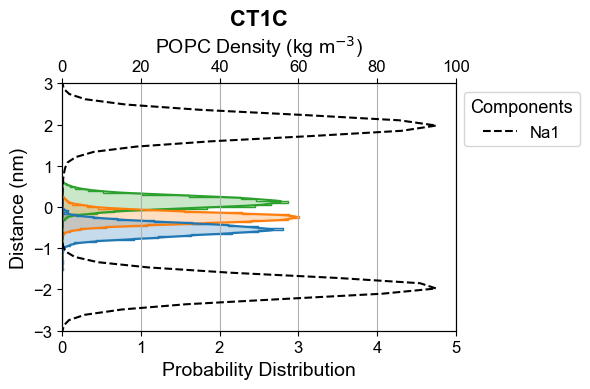

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the distance data
distance_data = pd.read_csv('/Users/chenyifang/Desktop/new_figure/CT1C.csv')

# Prepare data for plotting
melted_distance_data = distance_data.melt(var_name='Ion', value_name='Distance')

# Load the POPC density data (assuming it has columns 'Distance' and 'POPC')
popc_density_data = pd.read_csv('/Users/chenyifang/Desktop/new_figure/POPC_CT1C.csv')

# Plotting
fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot the probability distribution on the primary y-axis
sns.histplot(melted_distance_data, y='Distance', hue='Ion', stat='density', common_norm=False, element='step', kde=True, ax=ax1)
ax1.set_ylabel('Distance (nm)', fontsize=14)
ax1.set_xlabel('Probability Distribution', fontsize=14)
ax1.set_ylim([-3, 3])  # Adjust y limits as needed
ax1.set_xlim([0, 5])  # Adjust x limits as needed
ax1.tick_params(axis='both', which='major', labelsize=12)

# Plot the POPC density on the secondary x-axis
ax2 = ax1.twiny()
popc_line, = ax2.plot(popc_density_data['POPC'], popc_density_data['Distance'], color='black', linestyle='--', label='--POPC')
ax2.set_xlabel('POPC Density (kg m$^{-3}$)', fontsize=14)
ax2.set_xlim([0, 100])  # Adjust secondary x limits as needed
ax2.tick_params(axis='x', which='major', labelsize=12)

# Custom labels for ions
ion_handles, ion_labels = ax1.get_legend_handles_labels()
ion_labels = ['Na1', 'Na2', 'Cl$^-$', 'POPC']  # Set correct labels

# Combine the legend handles and labels
handles = ion_handles + [popc_line]
labels = ion_labels + ['--POPC']

# Plot the legend
ax1.legend(handles, labels, title='Components', title_fontsize='13', fontsize='12', loc='upper left', bbox_to_anchor=(1, 1))

# Improving aesthetics
plt.title('CT1C', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('/Users/chenyifang/Desktop/new_figure/CT1C_ion_stability.png', dpi=600, bbox_inches='tight')
plt.grid(True)
plt.rcParams['font.sans-serif'] = ['Arial']
# Show plot
plt.show()


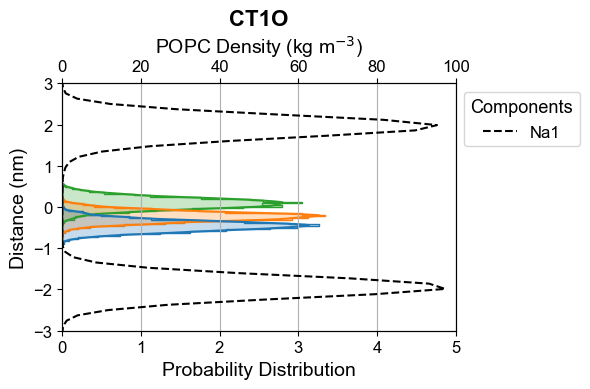

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the distance data
distance_data = pd.read_csv('/Users/chenyifang/Desktop/new_figure/CT1O.csv')

# Prepare data for plotting
melted_distance_data = distance_data.melt(var_name='Ion', value_name='Distance')

# Load the POPC density data (assuming it has columns 'Distance' and 'POPC')
popc_density_data = pd.read_csv('/Users/chenyifang/Desktop/new_figure/POPC_CT1O.csv')

# Plotting
fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot the probability distribution on the primary y-axis
sns.histplot(melted_distance_data, y='Distance', hue='Ion', stat='density', common_norm=False, element='step', kde=True, ax=ax1)
ax1.set_ylabel('Distance (nm)', fontsize=14)
ax1.set_xlabel('Probability Distribution', fontsize=14)
ax1.set_ylim([-3, 3])  # Adjust y limits as needed
ax1.set_xlim([0, 5])  # Adjust x limits as needed
ax1.tick_params(axis='both', which='major', labelsize=12)

# Plot the POPC density on the secondary x-axis
ax2 = ax1.twiny()
popc_line, = ax2.plot(popc_density_data['POPC'], popc_density_data['Distance'], color='black', linestyle='--', label='--POPC')
ax2.set_xlabel('POPC Density (kg m$^{-3}$)', fontsize=14)
ax2.set_xlim([0, 100])  # Adjust secondary x limits as needed
ax2.tick_params(axis='x', which='major', labelsize=12)

# Custom labels for ions
ion_handles, ion_labels = ax1.get_legend_handles_labels()
ion_labels = ['Na1', 'Na2', 'Cl$^-$', 'POPC']  # Set correct labels

# Combine the legend handles and labels
handles = ion_handles + [popc_line]
labels = ion_labels + ['--POPC']

# Plot the legend
ax1.legend(handles, labels, title='Components', title_fontsize='13', fontsize='12', loc='upper left', bbox_to_anchor=(1, 1))

# Improving aesthetics
plt.title('CT1O', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('/Users/chenyifang/Desktop/new_figure/CT1O_ion_stability.png', dpi=600, bbox_inches='tight')
plt.grid(True)
plt.rcParams['font.sans-serif'] = ['Arial']
# Show plot
plt.show()


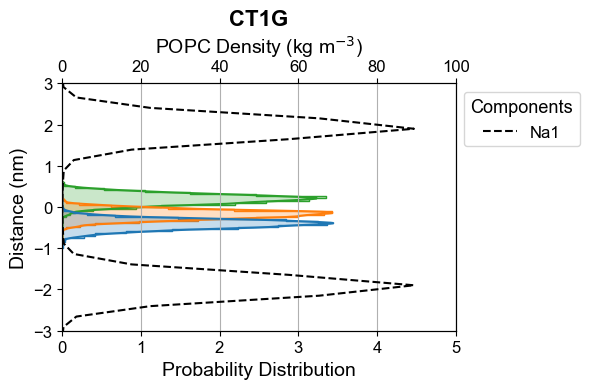

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the distance data
distance_data = pd.read_csv('/Users/chenyifang/Desktop/new_figure/CT1G.csv')

# Prepare data for plotting
melted_distance_data = distance_data.melt(var_name='Ion', value_name='Distance')

# Load the POPC density data (assuming it has columns 'Distance' and 'POPC')
popc_density_data = pd.read_csv('/Users/chenyifang/Desktop/new_figure/POPC_CT1G.csv')

# Plotting
fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot the probability distribution on the primary y-axis
sns.histplot(melted_distance_data, y='Distance', hue='Ion', stat='density', common_norm=False, element='step', kde=True, ax=ax1)
ax1.set_ylabel('Distance (nm)', fontsize=14)
ax1.set_xlabel('Probability Distribution', fontsize=14)
ax1.set_ylim([-3, 3])  # Adjust y limits as needed
ax1.set_xlim([0, 5])  # Adjust x limits as needed
ax1.tick_params(axis='both', which='major', labelsize=12)

# Plot the POPC density on the secondary x-axis
ax2 = ax1.twiny()
popc_line, = ax2.plot(popc_density_data['POPC'], popc_density_data['Distance'], color='black', linestyle='--', label='--POPC')
ax2.set_xlabel('POPC Density (kg m$^{-3}$)', fontsize=14)
ax2.set_xlim([0, 100])  # Adjust secondary x limits as needed
ax2.tick_params(axis='x', which='major', labelsize=12)

# Custom labels for ions
ion_handles, ion_labels = ax1.get_legend_handles_labels()
ion_labels = ['Na1', 'Na2', 'Cl$^-$', 'POPC']  # Set correct labels

# Combine the legend handles and labels
handles = ion_handles + [popc_line]
labels = ion_labels + ['--POPC']

# Plot the legend
ax1.legend(handles, labels, title='Components', title_fontsize='13', fontsize='12', loc='upper left', bbox_to_anchor=(1, 1))

# Improving aesthetics
plt.title('CT1G', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('/Users/chenyifang/Desktop/new_figure/CT1G_ion_stability.png', dpi=600, bbox_inches='tight')
plt.grid(True)
plt.rcParams['font.sans-serif'] = ['Arial']
# Show plot
plt.show()
